Ida Boregrim, Manfred Clase, Samuel Flodin - Found

**fetstil**# A first analysis of the COMPAS dataset

## Dataset description

We will examine the ProPublica COMPAS dataset, which contains the records of all criminal defendants who were subject to COMPAS screening in Broward County, Florida, during 2013 and 2014. For each defendant, various information fields (‘features’) were gathered by ProPublica. Broadly, these fields are related to the defendant’s demographic information (e.g., gender and race), criminal history (e.g., the number of prior offenses) and administrative information about the case (e.g., the case number, arrest date). Finally, the dataset contains the risk of recidivism predicted by the COMPAS tool, and also information about whether the defendant did actually recidivate or not (ground truth label for us).

The COMPAS score uses answers to 137 questions to assign a risk score to defendants -- essentially an estimate of the likelihood of re-arrest. The actual output is two-fold: a risk rating of 1-10 and a "low", "medium", or "high" risk label.

Link to dataset: https://github.com/propublica/compas-analysis

The file we will analyze is: compas-scores-two-years.csv

Link to the ProPublica article:

https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing

Some of the code below is adapted from the Propublica github repository above, and from

https://investigate.ai/propublica-criminal-sentencing/week-5-1-machine-bias-class/

## Download the data

We first need to load the data from the ProPublica repo:
https://github.com/propublica/compas-analysis

In [ ]:
%matplotlib inline

import urllib.request
import os,sys
import numpy as np
import pandas as pd

from sklearn import feature_extraction
from sklearn import preprocessing
from random import seed, shuffle

SEED = 1234
seed(SEED)
np.random.seed(SEED)

def check_data_file(fname):
    files = os.listdir(".") # get the current directory listing
    print("Looking for file '%s' in the current directory...",fname)

    if fname not in files:
        print("'%s' not found! Downloading from GitHub...",fname)
        addr = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
        response = urllib.request.urlopen(addr)
        data = response.read()
        fileOut = open(fname, "wb")
        fileOut.write(data)
        fileOut.close()
        print("'%s' download and saved locally..",fname)
    else:
        print("File found in current directory..")

COMPAS_INPUT_FILE = "compas-scores-two-years.csv"
check_data_file(COMPAS_INPUT_FILE)

Looking for file '%s' in the current directory... compas-scores-two-years.csv
File found in current directory..


## Loading and cleaning data

The following code load the data using pandas and cleans it according to ProPublica's cleaning:

"
If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.

We coded the recidivist flag -- is_recid -- to be -1 if we could not find a compas case at all.

In a similar vein, ordinary traffic offenses -- those with a c_charge_degree of 'O' -- will not result in Jail time are removed

We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility."
"

Finally, it converts the data to a dictionary with np arrays, which will be useful later

In [ ]:
# load the file
df = pd.read_csv(COMPAS_INPUT_FILE)
# print(df.shape)

df = df.dropna(subset=["days_b_screening_arrest"]) # dropping missing vals

df = df[
    (df.days_b_screening_arrest <= 30) &
    (df.days_b_screening_arrest >= -30) &
    (df.is_recid != -1) &
    (df.c_charge_degree != 'O') &
    (df.score_text != 'N/A')
]

df.reset_index(inplace=True, drop=True) # renumber the rows from 0 again
# df.shape

# Conversion to dictionary with np arrays
data = df.to_dict('list')
for k in data.keys():
    data[k] = np.array(data[k])

## Exploring the dataset

The following pandas commands are very convenient to explore the data. Uncomment them to explore the data.

<span style="color:red">TODO</span>: Add a command to print the number of defendents per race.

In the following, we will look mostly at African-Americans and Caucasians(termed blacks and whites for short)

In [ ]:
df.head() # check some examples of data
df.columns # prints the features
# df.isnull().sum() #check for missing values
# df.describe() # generates descriptive statistics (e.g., to check for outliers)
# df.race.unique() # different races we have in the dataset
# df.age_cat.value_counts() #number of people by age category
# df.score_text.value_counts() #number of people by COMPAS risk category

# TODO: Insert your code below this
#df.race.value_counts()

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

## Basic analysis of demographics

1. What are the different races present in the dataset?

2. What is the number of people by age category?

3. What is the number of people by race?

4. What is the number of people by COMPAS score (decile_score)?

5.  What is the number of people by COMPAS risk category (score_text)?

### 1. and 3. Different races present in the dataset

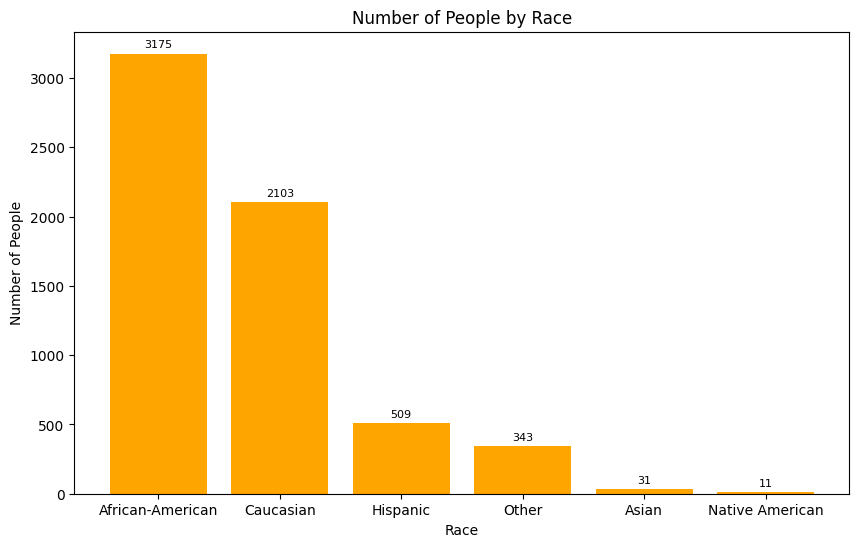

In [ ]:
import matplotlib.pyplot as plt

counts = df['race'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(counts.index.astype(str), counts.values, color='orange')

plt.title("Number of People by Race")
plt.xlabel("Race")
plt.ylabel("Number of People")

plt.bar_label(bars, padding=3, fontsize=8)

plt.show()

The above graph depicts the different races present in this dataset, as well as the amount of individuals per race.

### 2. Number of people by age category

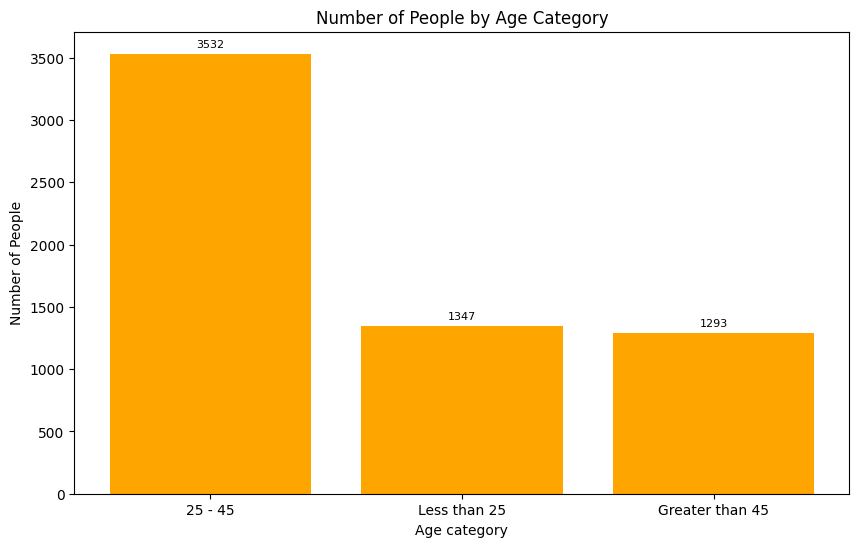

In [ ]:
counts = df['age_cat'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(counts.index.astype(str), counts.values, color='orange')

plt.title("Number of People by Age Category")
plt.xlabel("Age category")
plt.ylabel("Number of People")

plt.bar_label(bars, padding=3, fontsize=8)

plt.show()

The above graph shows the different age categories found in the dataset, as well as the number of individuals that are included in each age category.

### 4. Number of people by decile score

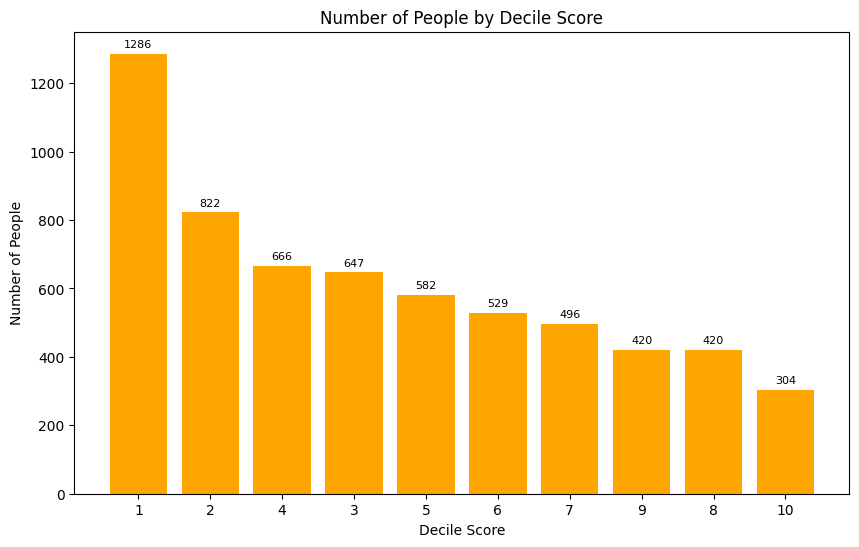

In [ ]:
counts = df['decile_score'].value_counts()

plt.figure(figsize=(10, 6))

bars = plt.bar(counts.index.astype(str), counts.values, color='orange')

plt.title("Number of People by Decile Score")
plt.xlabel("Decile Score")
plt.ylabel("Number of People")

plt.bar_label(bars, padding=3, fontsize=8)

plt.show()

The above graph depicts the number of people per decile score found in the dataset. The bars are divided into decile score, with the amount of individuals for each decile score also specified at the top of each bar.

### 5. Number of people by risk category

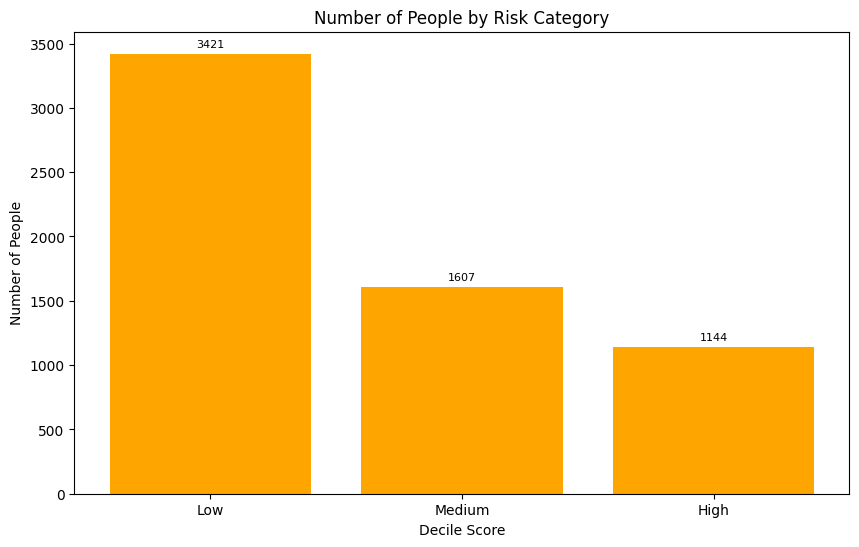

In [ ]:
counts = df['score_text'].value_counts()

plt.figure(figsize=(10, 6))

bars = plt.bar(counts.index.astype(str), counts.values, color='orange')

plt.title("Number of People by Risk Category")
plt.xlabel("Decile Score")
plt.ylabel("Number of People")

plt.bar_label(bars, padding=3, fontsize=8)

plt.show()

The dataset includes an attribute that divide the individuals into risk category. The number of people per risk category is shown in the above graph.

## Basic investigations of gender and race bias in COMPAS scores

decile_score -- is the score given by the COMPAS algorithm that estimates the risk to re-offend.

score_text -- is the level of risk: Low, Medium, High

two_years_recid -- is the ground truth data on whether the offender recidivated or not

- What is the mean COMPAS score (decile_score) per race and gender?

- What is the distribution (histogram) of decile_score per race and gender?

The two_year_recid field records whether or not each person was re-arrested for a violent offense within two years, which is what COMPAS is trying to predict.

- How many people were re-arrested?

- Compute the recidivism (i.e., people that got re-arrested) rates by race and gender

- What is the accuracy of the COMPAS scores to predict recidivism

- Is the accuracy higher/lower if we look at particular races/genders?

- What about false positives and false negatives?


## Average decile score by race

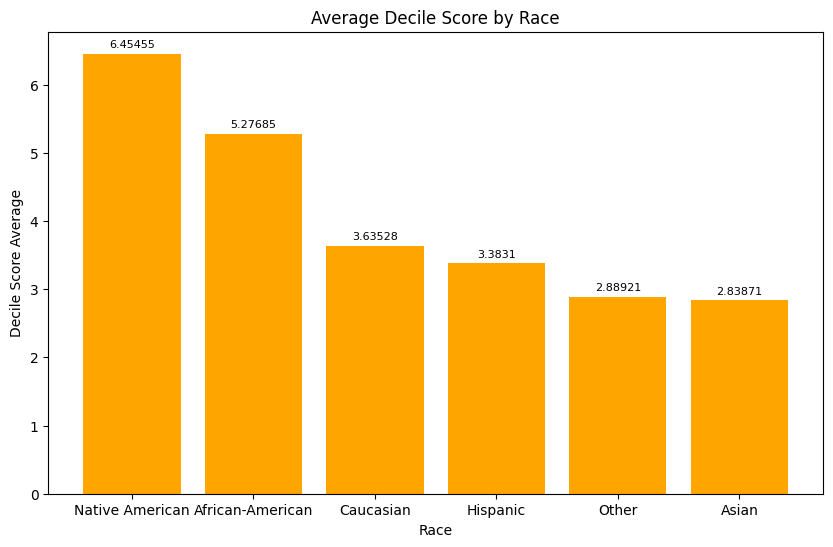

In [ ]:
avg_decile = df.groupby('race')['decile_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(avg_decile.index.astype(str), avg_decile.values, color='orange')

plt.title("Average Decile Score by Race")
plt.xlabel("Race")
plt.ylabel("Decile Score Average")

plt.bar_label(bars, padding=3, fontsize=8)

plt.show()

For the graph above, the decile score has been divided up amongst the races found in the dataset. This graph therefore depicts the average decile score by race.

## Average Decile Score by Gender

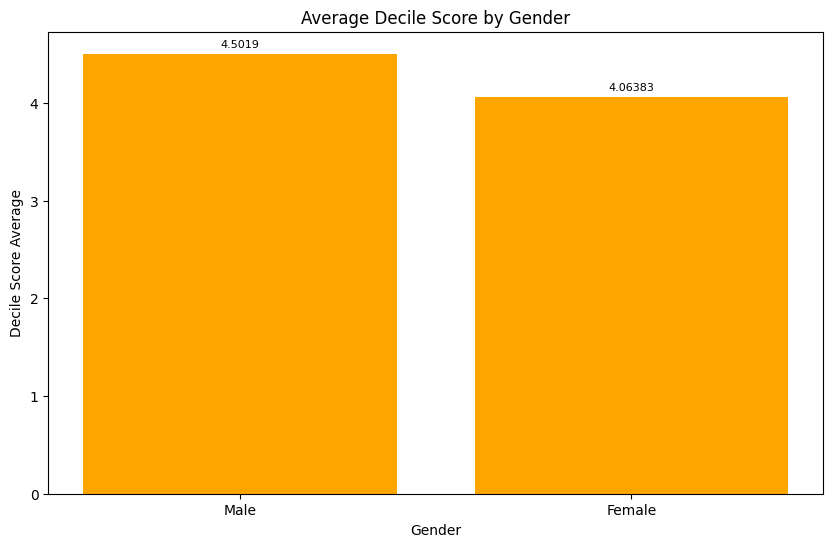

In [ ]:
avg_decile = df.groupby('sex')['decile_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(avg_decile.index.astype(str), avg_decile.values, color='orange')

plt.title("Average Decile Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Decile Score Average")

plt.bar_label(bars, padding=3, fontsize=8)

plt.show()

In the above graph, the decile score by gender, which is show in the two bars.

## Basic analysis of the bias in COMPAS scores

We now look at the COMPAS scores (deciles first, then text scores) as a function of the sensitive attribute (race or gender) to observe potential differences.

We start by observing the scores for different groupes.

<span style="color:red">TODO</span>: Plot the histograms of decile scores for Black and White defendant and observe the difference.

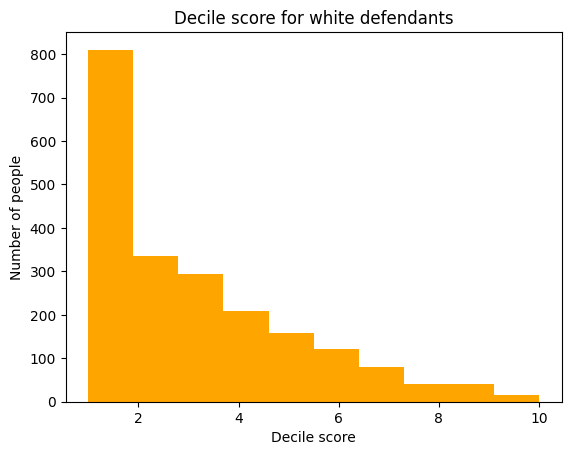

Text(0, 0.5, 'Number of people')

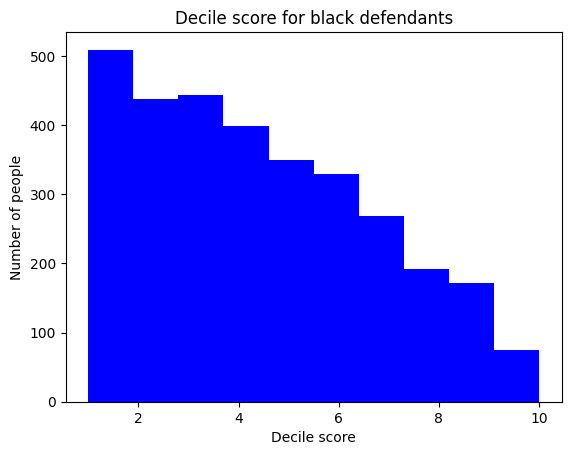

In [ ]:
# Histogram of decile scores for Blacks (blue) and Whites (orange)
# TODO: Insert your code below this
whitedf = df[df.race == "Caucasian"]
blackdf = df[df.race == "African-American"]

import matplotlib.pyplot as plt

plt.figure()
plt.hist(whitedf.v_decile_score, color = 'orange')
plt.title("Decile score for white defendants")
plt.xlabel("Decile score")
plt.ylabel("Number of people")
plt.show()

plt.figure()
plt.hist(blackdf.v_decile_score, color = 'blue')
plt.title("Decile score for black defendants")
plt.xlabel("Decile score")
plt.ylabel("Number of people")

The above observation can be explained by a dependence between the race and true label.

In [ ]:
# recidivism rates by race
recid_race = pd.crosstab(df.race, df.two_year_recid)
recid_race['rate'] = recid_race[1] / recid_race.sum(axis=1)
recid_race

two_year_recid,0,1,rate
race,,,
African-American,1514,1661,0.523150
Asian,23,8,0.258065
Caucasian,1281,822,0.390870
Hispanic,320,189,0.371316
Native American,6,5,0.454545
Other,219,124,0.361516


We now look at whether we observe a similar phenomenon on the text scores of COMPAS (low, medium, high risk).

In [ ]:
# high risk rates by race
score_race = pd.crosstab(df.race, df.score_text)
score_race['High risk rate'] = score_race['High'] / score_race.sum(axis=1)
score_race

score_text,High,Low,Medium,High risk rate
race,,,,
African-American,845,1346,984,0.266142
Asian,3,24,4,0.096774
Caucasian,223,1407,473,0.106039
Hispanic,47,368,94,0.092338
Native American,4,3,4,0.363636
Other,22,273,48,0.064140


### Fairness metrics for the COMPAS scores

We do not have the actual scores that are used to compte text scores Low-Med-High; hence we cannot investigate directly the calibration. However, we can use the decile score as a proxy, and we can investigate PPV.

Let us first plot the probability of recidivism by decile score. We observe that it is not very far from a diagonale.

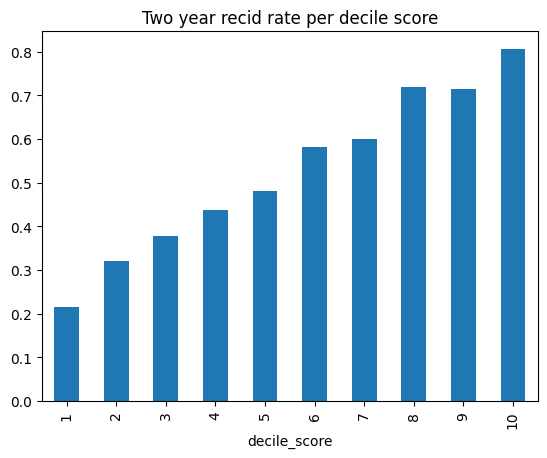

In [ ]:
# probability of recidivism by decile
res = df.groupby(df.decile_score)['two_year_recid'].mean().plot(kind='bar', title='Two year recid rate per decile score')

Two year recid rate per decile score with separated bars for Blacks and Whites:

Text(0, 0.5, 'Two year recid rate')

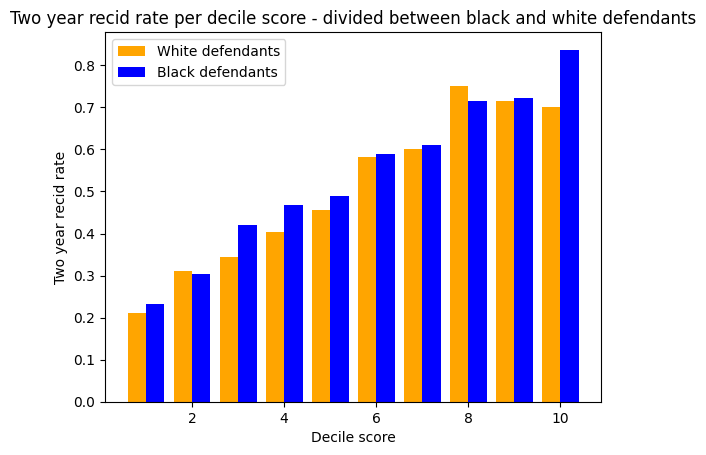

In [ ]:
# probability of recidivism by decile and race
# TODO: Insert your code below this
whiteres = whitedf.groupby(whitedf.decile_score)['two_year_recid'].mean()
whiteres.head()
blackres = blackdf.groupby(blackdf.decile_score)['two_year_recid'].mean()

w, x = 0.4, np.linspace(1,10,10)
fig, ax = plt.subplots()
ax.bar(x-w/2, whiteres, width = w, color = 'orange', label = 'White defendants')
plt.bar(x + w/2, blackres, width = w, color = 'blue', label = 'Black defendants')
plt.legend()
plt.title('Two year recid rate per decile score - divided between black and white defendants')
plt.xlabel('Decile score')
plt.ylabel('Two year recid rate')

To further analyze the COMPAS score as a classifier, we transform it into a binary outcome by splitting "low" (class 0) from "medium or high" risk (class 1). We can then compute standard quantities such as the confusion matrix or PPV.

In [ ]:
# COMPAS recidivism confusion matrix
df['guessed_recid'] = df.score_text != 'Low'
df['actual_recid'] = df.two_year_recid == 1
cm = pd.crosstab(df.actual_recid, df.guessed_recid)
cm # for "confusion matrix"

guessed_recid,False,True
actual_recid,,
False,2345,1018
True,1076,1733


We finally compute the PPV, TPR and FPR of the COMPAS classifier.

<span style="color:red">TODO</span>: Complete the print_ppv_fpv function. Observe the differences in the metrics between Blacks and Whites and comment.

In [ ]:
# cm is a confusion matrix. The rows are guessed, the columns are actual
def print_ppv_fpv(cm):
    # the indices here are [col][row] or [actual][guessed]
    TN = cm[False][False]
    TP = cm[True][True]
    FN = cm[True][False]
    FP = cm[False][True]
# TODO: Uncomment the lines below and replace the by the appropriate expressions of TN, TP, FN, FP
    print('Accuracy: ', (TP+TN)/(TP+TN+FN+FP))
    print('PPV: ', TP/(TP+FP))
    print('FPR: ', FP/(FP+TN))
    print('FNR: ', FN/(TP+FN))
    print()
#


def print_metrics(guessed, actual):
    cm = pd.crosstab(guessed, actual, rownames=['guessed'], colnames=['actual'])
    print(cm)
    print()
    print_ppv_fpv(cm)

print("All")
print_metrics(df.guessed_recid, df.actual_recid)

print('White')
subset = df[df.race == 'Caucasian']
print_metrics(subset.guessed_recid, subset.actual_recid)

print('Black')
subset = df[df.race == 'African-American']
print_metrics(subset.guessed_recid, subset.actual_recid)

All
actual   False  True 
guessed              
False     2345   1076
True      1018   1733

Accuracy:  0.6607258587167855
PPV:  0.6299527444565612
FPR:  0.30270591733571217
FNR:  0.38305446778212887

White
actual   False  True 
guessed              
False      999    408
True       282    414

Accuracy:  0.6718972895863052
PPV:  0.5948275862068966
FPR:  0.22014051522248243
FNR:  0.49635036496350365

Black
actual   False  True 
guessed              
False      873    473
True       641   1188

Accuracy:  0.6491338582677165
PPV:  0.6495352651722253
FPR:  0.4233817701453104
FNR:  0.2847682119205298



`Conclusion`: the False Positive Rate is substantially higher for black defendants, but the PPV is similar between blacks and whites. That is, the COMPAS score satisfies sufficiency, but not separation.

## Training a classifier from the ground truth label

We now train a classifier (a simple logistic regression) on the label two_year_recid. We work on a subset of features: ["age_cat", "race", "sex", "priors_count", "c_charge_degree"].

<span style="color:red">TODO</span>: Complete the model definition and fitting.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from collections import defaultdict

FEATURES_CLASSIFICATION = ["age_cat", "race", "sex", "priors_count", "c_charge_degree"] #features to be used for classification
CONT_VARIABLES = ["priors_count"] # continuous features, will need to be handled separately from categorical features, categorical features will be encoded using one-hot
CLASS_FEATURE = "two_year_recid" # the decision variable
SENSITIVE_ATTRS = ["race"]


y = data[CLASS_FEATURE]
X = np.array([]).reshape(len(y), 0) # empty array with num rows same as num examples, will hstack the features to it
x_control = defaultdict(list)

for attr in FEATURES_CLASSIFICATION:
    vals = data[attr]
    if attr in CONT_VARIABLES:
        vals = [float(v) for v in vals]
        vals = preprocessing.scale(vals) # 0 mean and 1 variance
        vals = np.reshape(vals, (len(y), -1)) # convert from 1-d arr to a 2-d arr with one col

    else: # this encodes categorical variables in a numerical way -- there are other ways to do it
        enc = preprocessing.LabelBinarizer()
        enc.fit(vals)
        vals = enc.transform(vals)

    # add to learnable features
    X = np.hstack((X, vals))


# the following is a very dirty way to keep track of the race after the train_test_split
ind = data["race"]=="African-American"
X_b = X[ind]
y_b = y[ind]
ind = data["race"]=="Caucasian"
X_w = X[ind]
y_w = y[ind]
ind = [data["race"][i]!="Caucasian" and data["race"][i]!="African-American" for i in range(len(y))]
X_n = X[ind]
y_n = y[ind]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.3, random_state=1234)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.3, random_state=5678)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_n, y_n, test_size=0.3, random_state=9012)

X_train = np.vstack((X_train_b, X_train_w, X_train_n))
y_train = np.hstack((y_train_b, y_train_w, y_train_n))
X_test = np.vstack((X_test_b, X_test_w, X_test_n))
y_test = np.hstack((y_test_b, y_test_w, y_test_n))


# TODO: Uncomment and complete the code below
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

We can then compute the model accuracy. Compare to the COMPAS accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))

# COMPAS had 66.07%, so very similar.

Accuracy: 0.6540744738262277


We can also plot the ROC curve for the model on the global population.

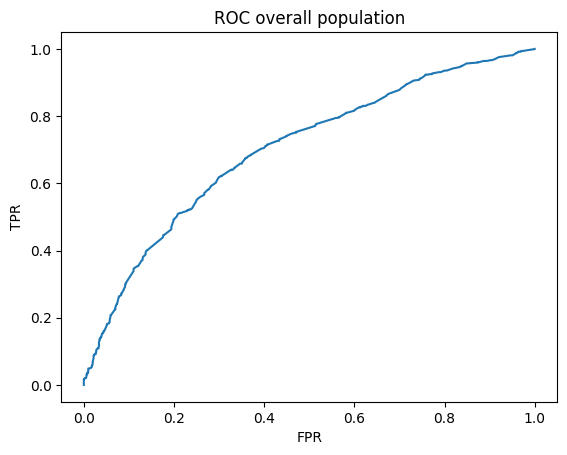

In [ ]:
from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])

plt.plot(fpr, tpr)

plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


<span style="color:red">TODO</span>: Plot the ROC curve for Blacks and Whites in two separate curves (in the same plot). What do you observe?

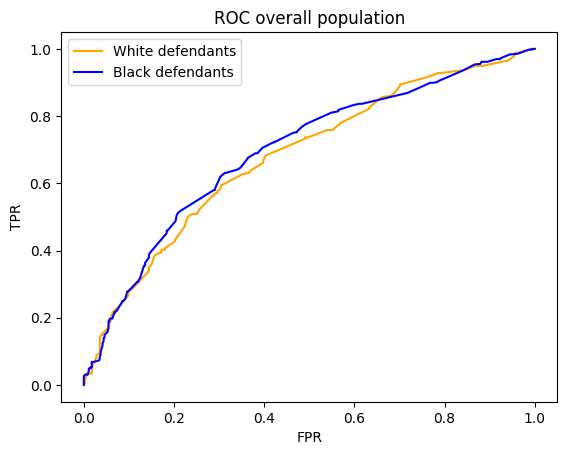

In [ ]:
# TODO: Insert your code below this line
whitescores = model.predict_proba(X_test_w)
blackscores = model.predict_proba(X_test_b)
whitefpr, whitetpr, thresholds = roc_curve(y_test_w, whitescores[:,1])
blackfpr, blacktpr, thresholds = roc_curve(y_test_b, blackscores[:,1])

plt.plot(whitefpr, whitetpr, label = 'White defendants', color = 'orange')
plt.plot(blackfpr, blacktpr, label= 'Black defendants', color = 'blue')
plt.legend()

plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

We can finally check the fairness of this simple logistic regression, when choosing an arbitrary threshold common to the two groups.

<span style="color:red">TODO</span>: Compute the predictions for a common threshold (threshold_common), then compute the PPV, TPR, FPR (you can use the print_metrics function from above). Comment.

In [ ]:
threshold_common = 0.5
# TODO: Insert your code below this line
whitepred = np.zeros(len(whitescores),)
blackpred = np.zeros(len(blackscores),)
for i in range(len(whitescores)):
  if (whitescores[i,1] >= threshold_common):
    whitepred[i] = 1
for i in range(len(blackscores)):
  if blackscores[i, 1] >= threshold_common:
    blackpred[i] = 1

print("White dataset")
print_metrics(whitepred.astype(bool), y_test_w.astype(bool))
print()
print("Black dataset")
print_metrics(blackpred.astype(bool), y_test_b.astype(bool))

#Lower FPR overall but still unfair

White dataset
actual   False  True 
guessed              
False      324    141
True        71     95

Accuracy:  0.6640253565768621
PPV:  0.572289156626506
FPR:  0.17974683544303796
FNR:  0.597457627118644


Black dataset
actual   False  True 
guessed              
False      298    175
True       159    321

Accuracy:  0.6495278069254984
PPV:  0.66875
FPR:  0.3479212253829322
FNR:  0.3528225806451613



Finally, we can also investigate the calibration more finely using the calibration module from sklearn.



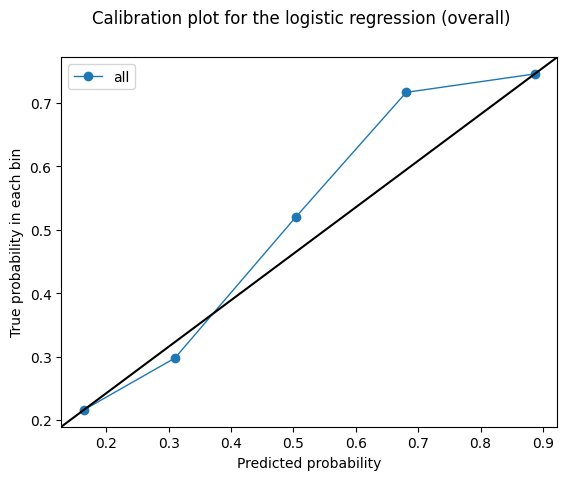

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms

# TODO: Uncomment and complete the code below
all_scores = scores[:,1]

prob_true, prob_pred = calibration_curve(y_test, all_scores)

fig, ax = plt.subplots()
# only this line is calibration curves
plt.plot(prob_pred,prob_true, marker='o', linewidth=1, label='all')

# reference line, legends, and axis labels
line = mlines.Line2D([0, 1], [0, 1], color='black')
transform = ax.transAxes
line.set_transform(transform)
ax.add_line(line)
fig.suptitle('Calibration plot for the logistic regression (overall)')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('True probability in each bin')
plt.legend()
plt.show()

Below is plotting of the calibration curve for the blacks and white separately.

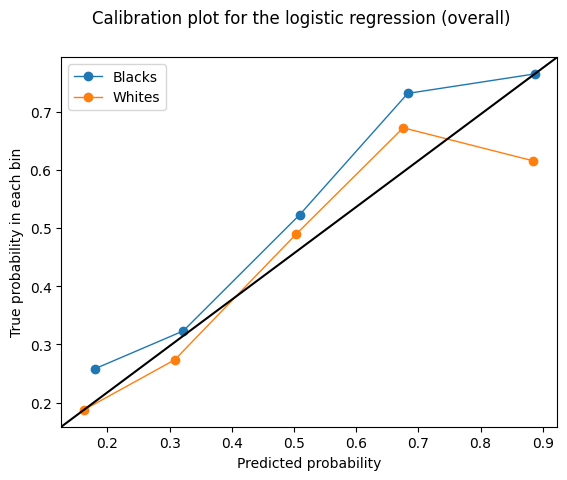

In [ ]:
# TODO: Uncomment and complete the code below

prob_true_b, prob_pred_b = calibration_curve(y_test_b, blackscores[:,1])
# ...
prob_true_w, prob_pred_w = calibration_curve(y_test_w, whitescores[:,1])


fig, ax = plt.subplots()
# only this line is calibration curves
plt.plot(prob_pred_b,prob_true_b, marker='o', linewidth=1, label='Blacks')
plt.plot(prob_pred_w,prob_true_w, marker='o', linewidth=1, label='Whites')

# reference line, legends, and axis labels
line = mlines.Line2D([0, 1], [0, 1], color='black')
transform = ax.transAxes
line.set_transform(transform)
ax.add_line(line)
fig.suptitle('Calibration plot for the logistic regression (overall)')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('True probability in each bin')
plt.legend()
plt.show()

The calibration curve shows predicted probability compared to true probability. Perfect calibration is the straight line.

In fairness this can be related to the notion of sufficiency. If the model is sufficient then the curves for the two groups should look the same. They look similar.



**Training of our own model**

We decided two models were trained: one Decision Tree Classifier and one KNN-classfier. Initially we included the race feature which we later removed to compare perfomance. We experimented with different sets of features, such as prior

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from collections import defaultdict

FEATURES_CLASSIFICATION = ["age_cat", "race", "sex", "priors_count", "c_charge_degree"] #features to be used for classification
CONT_VARIABLES = ["priors_count"] # continuous features, will need to be handled separately from categorical features, categorical features will be encoded using one-hot
CLASS_FEATURE = "two_year_recid" # the decision variable
SENSITIVE_ATTRS = ["race"]


y = data[CLASS_FEATURE]
X = np.array([]).reshape(len(y), 0) # empty array with num rows same as num examples, will hstack the features to it
FEATURE_NAMES = []
x_control = defaultdict(list)

for attr in FEATURES_CLASSIFICATION:
    vals = data[attr]
    if attr in CONT_VARIABLES:
        vals = [float(v) for v in vals]
        vals = preprocessing.scale(vals) # 0 mean and 1 variance
        vals = np.reshape(vals, (len(y), -1)) # convert from 1-d arr to a 2-d arr with one col
        FEATURE_NAMES.append(attr)
    else: # this encodes categorical variables in a numerical way -- there are other ways to do it
        enc = preprocessing.LabelBinarizer()
        enc.fit(vals)
        vals = enc.transform(vals)
        if vals.ndim == 1:
            vals = np.reshape(vals, (len(y), -1))
            FEATURE_NAMES.append(attr)
        else:
            FEATURE_NAMES.extend([f"{attr}_{val}" for val in enc.classes_])

    # add to learnable features
    X = np.hstack((X, vals))


# the following is a very dirty way to keep track of the race after the train_test_split
ind = data["race"]=="African-American"
X_b = X[ind]
y_b = y[ind]
ind = data["race"]=="Caucasian"
X_w = X[ind]
y_w = y[ind]
ind = [data["race"][i]!="Caucasian" and data["race"][i]!="African-American" for i in range(len(y))]
X_n = X[ind]
y_n = y[ind]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.3, random_state=1234)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.3, random_state=5678)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_n, y_n, test_size=0.3, random_state=9012)

X_train = np.vstack((X_train_b, X_train_w, X_train_n))
y_train = np.hstack((y_train_b, y_train_w, y_train_n))
X_test = np.vstack((X_test_b, X_test_w, X_test_n))
y_test = np.hstack((y_test_b, y_test_w, y_test_n))

KNN classifier was trained with hypreparameter neighbors set to N=5.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(5)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))


Accuracy: 0.6405828386400432


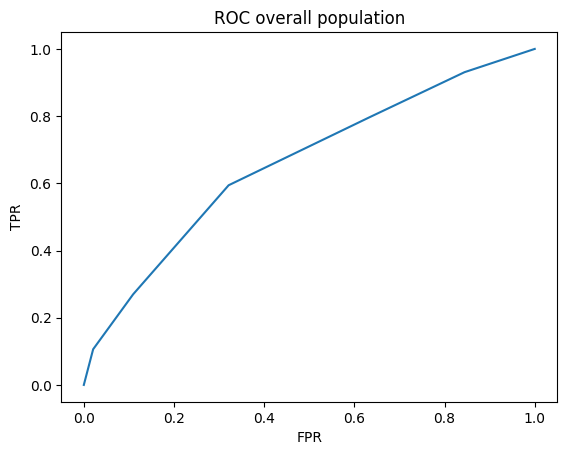

In [ ]:
from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])

plt.plot(fpr, tpr)

plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5,random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Accuracy: 0.6637884511602806


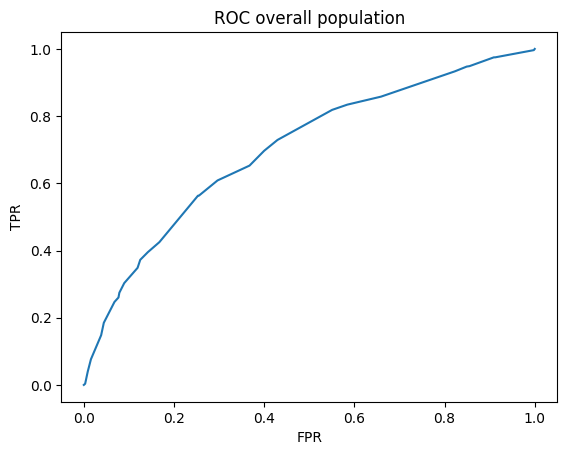

In [ ]:
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))


from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])

plt.plot(fpr, tpr)

plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


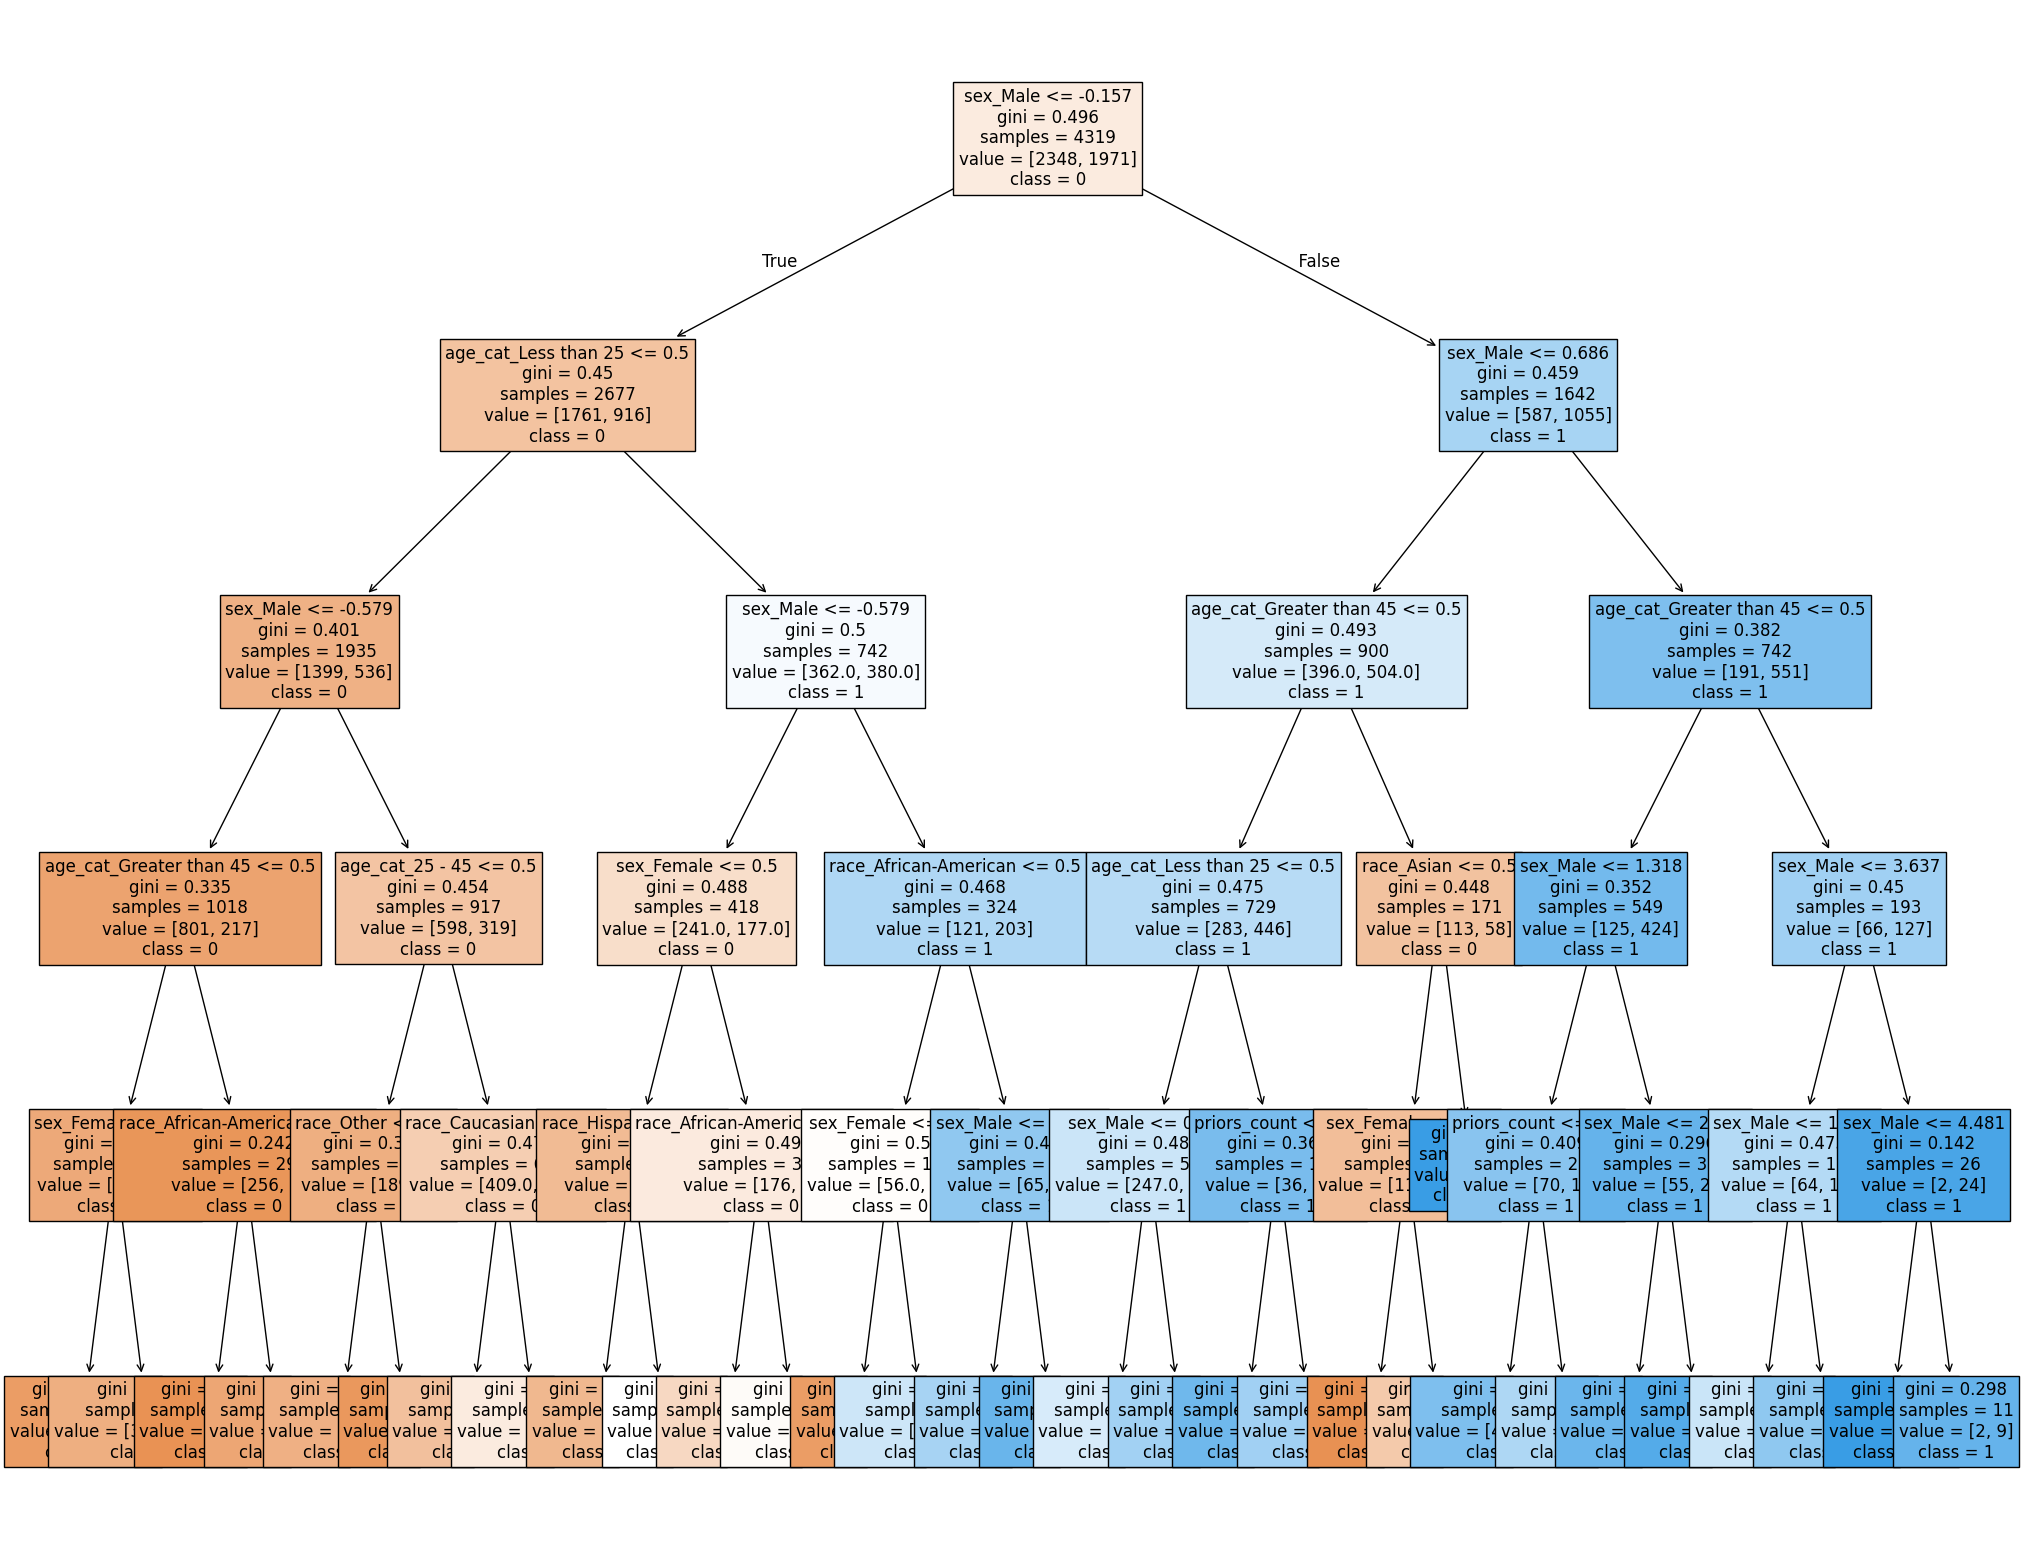

In [ ]:
from sklearn import tree

fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(model,
                   feature_names=FEATURE_NAMES,
                   class_names=[str(c) for c in model.classes_],
                   fontsize=12,
                   filled=True)

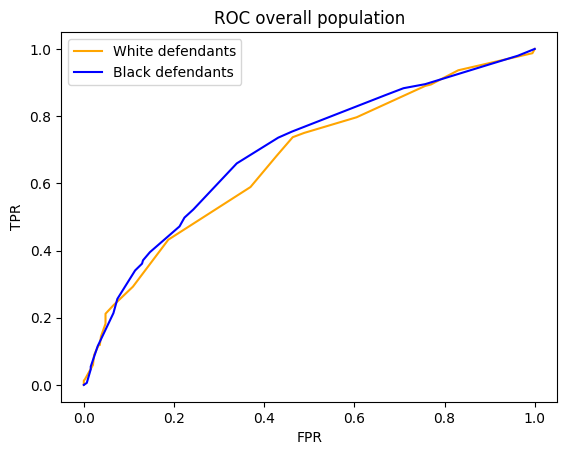

In [ ]:

whitescores = model.predict_proba(X_test_w)
blackscores = model.predict_proba(X_test_b)
scores = model.predict_proba(X_test)

whitefpr, whitetpr, thresholds = roc_curve(y_test_w, whitescores[:,1])
blackfpr, blacktpr, thresholds = roc_curve(y_test_b, blackscores[:,1])

plt.plot(whitefpr, whitetpr, label = 'White defendants', color = 'orange')
plt.plot(blackfpr, blacktpr, label= 'Black defendants', color = 'blue')
plt.legend()


plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [ ]:
threshold_common = 0.5
# TODO: Insert your code below this line
whitepred = np.zeros(len(whitescores),)
blackpred = np.zeros(len(blackscores),)
pred = np.zeros(len(scores),)
for i in range(len(whitescores)):
  if (whitescores[i,1] >= threshold_common):
    whitepred[i] = 1
for i in range(len(blackscores)):
  if blackscores[i, 1] >= threshold_common:
    blackpred[i] = 1
for i in range(len(scores)):
  if scores[i, 1] >= threshold_common:
    pred[i] = 1

print("Total dataset")
print_metrics(pred.astype(bool), y_test.astype(bool))

print("White dataset")
print_metrics(whitepred.astype(bool), y_test_w.astype(bool))
print()
print("Black dataset")
print_metrics(blackpred.astype(bool), y_test_b.astype(bool))

#Lower FPR overall but still unfair

Total dataset
actual   False  True 
guessed              
False      756    366
True       259    472

Accuracy:  0.6627091203453859
PPV:  0.6456908344733242
FPR:  0.25517241379310346
FNR:  0.43675417661097854

White dataset
actual   False  True 
guessed              
False      321    134
True        74    102

Accuracy:  0.6703645007923931
PPV:  0.5795454545454546
FPR:  0.18734177215189873
FNR:  0.5677966101694916


Black dataset
actual   False  True 
guessed              
False      302    169
True       155    327

Accuracy:  0.6600209863588667
PPV:  0.6784232365145229
FPR:  0.33916849015317285
FNR:  0.3407258064516129



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from collections import defaultdict

FEATURES_CLASSIFICATION = ["age_cat", "sex", "priors_count", "c_charge_degree"] #features to be used for classification
CONT_VARIABLES = ["priors_count"] # continuous features, will need to be handled separately from categorical features, categorical features will be encoded using one-hot
CLASS_FEATURE = "two_year_recid" # the decision variable
SENSITIVE_ATTRS = ["race"]


y = data[CLASS_FEATURE]
X = np.array([]).reshape(len(y), 0) # empty array with num rows same as num examples, will hstack the features to it
FEATURE_NAMES = []
x_control = defaultdict(list)

for attr in FEATURES_CLASSIFICATION:
    vals = data[attr]
    if attr in CONT_VARIABLES:
        vals = [float(v) for v in vals]
        vals = preprocessing.scale(vals) # 0 mean and 1 variance
        vals = np.reshape(vals, (len(y), -1)) # convert from 1-d arr to a 2-d arr with one col
        FEATURE_NAMES.append(attr)
    else: # this encodes categorical variables in a numerical way -- there are other ways to do it
        enc = preprocessing.LabelBinarizer()
        enc.fit(vals)
        vals = enc.transform(vals)
        if vals.ndim == 1:
            vals = np.reshape(vals, (len(y), -1))
            FEATURE_NAMES.append(attr)
        else:
            FEATURE_NAMES.extend([f"{attr}_{val}" for val in enc.classes_])

    # add to learnable features
    X = np.hstack((X, vals))


# the following is a very dirty way to keep track of the race after the train_test_split
ind = data["race"]=="African-American"
X_b = X[ind]
y_b = y[ind]
ind = data["race"]=="Caucasian"
X_w = X[ind]
y_w = y[ind]
ind = [data["race"][i]!="Caucasian" and data["race"][i]!="African-American" for i in range(len(y))]
X_n = X[ind]
y_n = y[ind]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.3, random_state=1234)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.3, random_state=5678)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_n, y_n, test_size=0.3, random_state=9012)

X_train = np.vstack((X_train_b, X_train_w, X_train_n))
y_train = np.hstack((y_train_b, y_train_w, y_train_n))
X_test = np.vstack((X_test_b, X_test_w, X_test_n))
y_test = np.hstack((y_test_b, y_test_w, y_test_n))




# TODO: Uncomment and complete the code below# ...

model = DecisionTreeClassifier(max_depth=5,random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Accuracy: 0.6659471127900701
[[0.87356322 0.12643678]
 [0.81958763 0.18041237]
 [0.44303797 0.55696203]
 ...
 [0.44303797 0.55696203]
 [0.44303797 0.55696203]
 [0.81958763 0.18041237]]


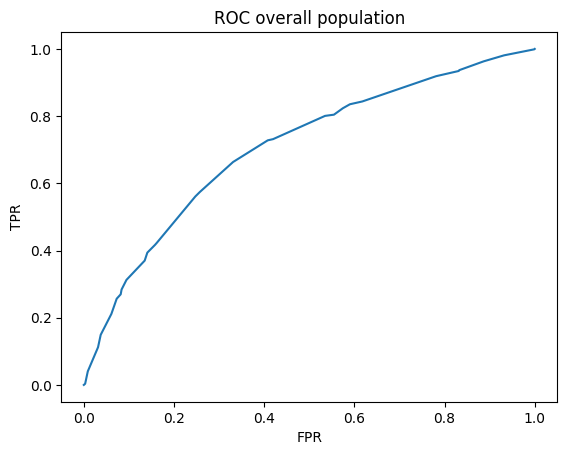

In [ ]:
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))


from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

scores = model.predict_proba(X_test)
print(scores)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])

plt.plot(fpr, tpr)

plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


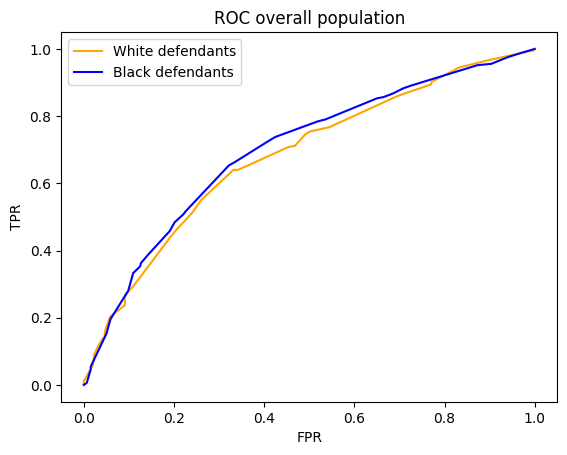

In [ ]:

whitescores = model.predict_proba(X_test_w)
blackscores = model.predict_proba(X_test_b)
scores = model.predict_proba(X_test)

whitefpr, whitetpr, thresholds = roc_curve(y_test_w, whitescores[:,1])
blackfpr, blacktpr, thresholds = roc_curve(y_test_b, blackscores[:,1])

plt.plot(whitefpr, whitetpr, label = 'White defendants', color = 'orange')
plt.plot(blackfpr, blacktpr, label= 'Black defendants', color = 'blue')
plt.legend()


plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [ ]:
threshold_common = 0.5
# TODO: Insert your code below this line
whitepred = np.zeros(len(whitescores),)
blackpred = np.zeros(len(blackscores),)
pred = np.zeros(len(scores),)
for i in range(len(whitescores)):
  if (whitescores[i,1] >= threshold_common):
    whitepred[i] = 1
for i in range(len(blackscores)):
  if blackscores[i, 1] >= threshold_common:
    blackpred[i] = 1
for i in range(len(scores)):
  if scores[i, 1] >= threshold_common:
    pred[i] = 1

print("Total dataset")
print_metrics(pred.astype(bool), y_test.astype(bool))

print("White dataset")
print_metrics(whitepred.astype(bool), y_test_w.astype(bool))
print()
print("Black dataset")
print_metrics(blackpred.astype(bool), y_test_b.astype(bool))

#Lower FPR overall but still unfair

Total dataset
actual   False  True 
guessed              
False      754    357
True       261    481

Accuracy:  0.6664867781975176
PPV:  0.6482479784366577
FPR:  0.2571428571428571
FNR:  0.42601431980906923

White dataset
actual   False  True 
guessed              
False      315    128
True        80    108

Accuracy:  0.6703645007923931
PPV:  0.574468085106383
FPR:  0.20253164556962025
FNR:  0.5423728813559322


Black dataset
actual   False  True 
guessed              
False      305    168
True       152    328

Accuracy:  0.664218258132214
PPV:  0.6833333333333333
FPR:  0.33260393873085337
FNR:  0.3387096774193548



In [ ]:
threshold_black = 0.6
threshold_white = 0.5
# TODO: Insert your code below this line
whitepred = np.zeros(len(whitescores),)
blackpred = np.zeros(len(blackscores),)
pred = np.zeros(len(scores),)
for i in range(len(whitescores)):
  if (whitescores[i,1] >= threshold_white):
    whitepred[i] = 1
for i in range(len(blackscores)):
  if blackscores[i, 1] >= threshold_black:
    blackpred[i] = 1
for i in range(len(scores)):
  if scores[i, 1] >= threshold_common:
    pred[i] = 1

print("Total dataset")
pred_conc = np.concatenate((whitepred, blackpred))
y_test_conc = np.concatenate((y_test_w, y_test_b))
print_metrics(pred_conc.astype(bool), y_test_conc.astype(bool))

print("White dataset")
print_metrics(whitepred.astype(bool), y_test_w.astype(bool))
print()
print("Black dataset")
print_metrics(blackpred.astype(bool), y_test_b.astype(bool))


Total dataset
actual   False  True 
guessed              
False      680    384
True       172    348

Accuracy:  0.648989898989899
PPV:  0.6692307692307692
FPR:  0.20187793427230047
FNR:  0.5245901639344263

White dataset
actual   False  True 
guessed              
False      315    128
True        80    108

Accuracy:  0.6703645007923931
PPV:  0.574468085106383
FPR:  0.20253164556962025
FNR:  0.5423728813559322


Black dataset
actual   False  True 
guessed              
False      365    256
True        92    240

Accuracy:  0.6348373557187827
PPV:  0.7228915662650602
FPR:  0.2013129102844639
FNR:  0.5161290322580645

